# 实验十四：新闻语料关键词提取对比

## 实验目标

1. 下载新闻文档集；
2. 对文档集进行清洗、分词和停用词过滤；
3. 分别使用 TF-IDF、TextRank、LSA 提取关键词；
4. 对比三种算法的关键词结果与适用特点。

## 数据集

本实验使用 `sklearn.datasets.fetch_20newsgroups` 下载 20 Newsgroups 新闻语料，选取 `sci.space`、`rec.sport.baseball`、`talk.politics.mideast`、`comp.graphics` 四类新闻，每类抽取最多 45 篇，保存为 `新闻语料_20类新闻.csv`。


## 1. 导入实验函数

具体算法实现保存在 `experiment14_keyword_extraction.py` 中，notebook 负责分步运行和展示结果。


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from experiment14_keyword_extraction import (
    CORPUS_PATH,
    RESULT_PATH,
    OVERLAP_PATH,
    PLOT_PATH,
    download_news_corpus,
    build_documents,
    extract_tfidf_keywords,
    extract_textrank_keywords,
    extract_lsa_keywords,
    enrich_result,
    compare_overlap,
    plot_keywords,
)


## 2. 下载并查看新闻语料


In [22]:
df = download_news_corpus()
print(df['category'].value_counts())
df.head()


发现本地语料缓存：新闻语料_20类新闻.csv，共 180 篇文档
category
sci.space                45
rec.sport.baseball       45
talk.politics.mideast    45
comp.graphics            45
Name: count, dtype: int64


,category,text
0,sci.space,Sounds liek what the FED has to do is sign a 5...
1,sci.space,\n\n\n\nFirst I've heard of it. Offhand:\n\nGr...
2,sci.space,The home office number for ENVIRONET is (301) ...
3,sci.space,"\n\nDennis, I have worked on or written propos..."
4,sci.space,\n\n\nNo. I estimate a 99 % probability the Ge...


## 3. 清洗文本并过滤停用词


In [23]:
token_docs, docs = build_documents(df)
print(token_docs[0][:30])


停用词过滤后保留 155 篇有效文档
总词数：26,785
不同词数：8,523
['sounds', 'liek', 'fed', 'sign', 'year', 'lease', 'certain', 'parts', 'space', 'station', 'built', 'designed', 'commerical', 'company', 'consortium', 'companies', 'alyeska', 'small', 'rent', 'return', 'certain', 'incentives', 'tax', 'right', 'monopoly', 'certain', 'products', 'commerical', 'builders', 'certain']


## 4. TF-IDF 提取关键词

TF-IDF 用词频和逆文档频率衡量关键词重要性，适合找出在部分文档中突出、但不是所有文档都常见的词。


In [24]:
tfidf_result = extract_tfidf_keywords(docs)
enrich_result(tfidf_result)


,算法,排名,英文关键词,中文关键词,得分
0,TF-IDF,1,space,太空,0.023742
1,TF-IDF,2,israel,以色列,0.023240
2,TF-IDF,3,year,年份,0.018873
3,TF-IDF,4,said,表示,0.018686
4,TF-IDF,5,armenians,亚美尼亚人,0.017355
5,TF-IDF,6,better,更好,0.016733
6,TF-IDF,7,thanks,感谢,0.015505
7,TF-IDF,8,program,程序,0.015037
8,TF-IDF,9,ftp,文件传输,0.014206
9,TF-IDF,10,need,需要,0.014101


## 5. TextRank 提取关键词

TextRank 将词看作图节点，在滑动窗口内建立共现边，再通过 PageRank 思想计算词的重要性。


In [25]:
textrank_result = extract_textrank_keywords(token_docs)
enrich_result(textrank_result)


,算法,排名,英文关键词,中文关键词,得分
0,TextRank,1,said,表示,6.496451
1,TextRank,2,armenians,亚美尼亚人,5.909007
2,TextRank,3,data,数据,5.655234
3,TextRank,4,space,太空,5.364735
4,TextRank,5,armenian,亚美尼亚,5.134388
5,TextRank,6,say,说,4.056936
6,TextRank,7,went,前往,3.754239
7,TextRank,8,available,可用,3.649647
8,TextRank,9,israel,以色列,3.567453
9,TextRank,10,image,图像,3.496886


## 6. LSA 提取关键词

LSA 先构建 TF-IDF 矩阵，再用 SVD 提取潜在语义主题。词在主要主题上的载荷越高，越能代表文档集的整体语义。


In [26]:
lsa_result = extract_lsa_keywords(docs)
enrich_result(lsa_result)


,算法,排名,英文关键词,中文关键词,得分
0,LSA,1,israel,以色列,0.016793
1,LSA,2,lost,失利,0.013741
2,LSA,3,armenians,亚美尼亚人,0.013543
3,LSA,4,won,获胜,0.012080
4,LSA,5,armenian,亚美尼亚,0.011679
5,LSA,6,ftp,文件传输,0.011123
6,LSA,7,space,太空,0.011012
7,LSA,8,israeli,以色列人,0.009263
8,LSA,9,files,文件,0.008187
9,LSA,10,baerga,贝尔加,0.008015


## 7. 结果对比


In [27]:
result = pd.concat([tfidf_result, textrank_result, lsa_result], ignore_index=True)
result_zh = enrich_result(result)
comparison_table = result_zh.pivot(index='排名', columns='算法', values='中文关键词')
comparison_table


算法,LSA,TF-IDF,TextRank
排名,,,
1,以色列,太空,表示
2,失利,以色列,亚美尼亚人
3,亚美尼亚人,年份,数据
4,获胜,表示,太空
5,亚美尼亚,亚美尼亚人,亚美尼亚
6,文件传输,更好,说
7,太空,感谢,前往
8,以色列人,程序,可用
9,文件,文件传输,以色列


In [28]:
overlap = compare_overlap(result)
result_zh.to_csv(RESULT_PATH, index=False, encoding='utf-8-sig')
overlap.to_csv(OVERLAP_PATH, encoding='utf-8-sig')
overlap


,LSA,TF-IDF,TextRank
算法,,,
LSA,15,7,5
TF-IDF,7,15,7
TextRank,5,7,15


中文对比图已保存：关键词提取算法对比图.png


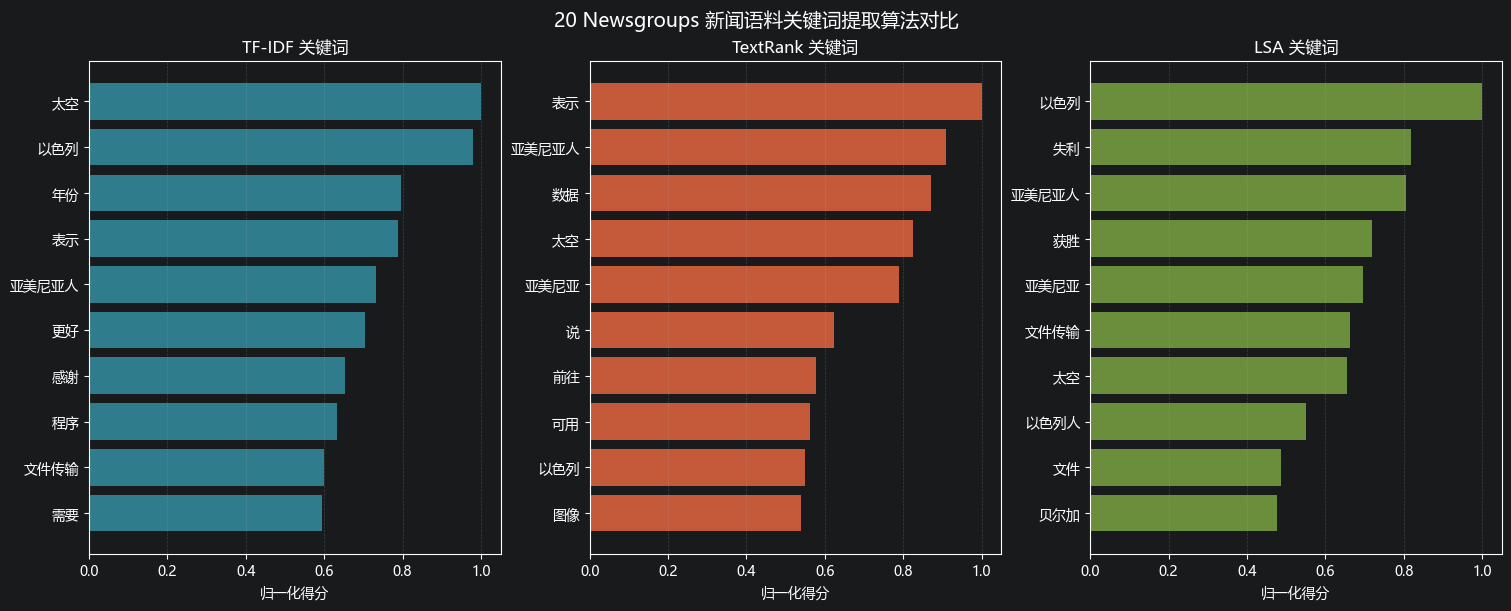

In [29]:
plot_keywords(result)
plt.show()


## 8. 实验结论

- **TF-IDF**：强调“在某些文档中高频、在整个语料中不过分常见”的词，适合提取具有类别区分度的关键词。
- **TextRank**：依赖词语共现网络，排名靠前的词通常与大量词共同出现，反映语料中的中心词。
- **LSA**：通过 SVD 得到潜在语义主题，关键词更偏向能够解释主要主题结构的词。
- 三种方法使用同一份停用词过滤后的新闻语料，但建模角度不同，因此结果既有重合，也会出现明显差异。
